# Day 17 - SQL Subquery Customer Analysis

서브쿼리를 이용해 고객별 주문 수, 최초 주문일, 마지막 주문일을 계산하고 전체 고객 평균 주문 수와 비교한다.

## 분석 목적

기존 Day 16에서는 고정된 주문 횟수 기준으로 고객 활동 수준을 분류했다.

이번 분석에서는 고정 숫자가 아니라 데이터에서 계산한 전체 고객 평균 주문 수를 기준으로 고객 활동을 비교한다.

## 분석 질문

1. 고객별 전체 주문 수는 몇 건인가?
2. 고객별 최초 주문일과 마지막 주문일은 언제인가?
3. 전체 고객의 평균 주문 수는 몇 건인가?
4. 평균보다 주문 수가 많은 고객은 누구인가?
5. 주문 이력이 없는 고객은 누구인가?

In [1]:
# 라이브러리 불러오기
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = study_root / "SQL" / "database" / "retail_lab.db"
output_dir = project_root / "outputs"

output_dir.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", project_root)
print("데이터베이스 경로:", db_path)
print("출력 폴더:", output_dir)

프로젝트 루트: d:\Study\Projects\00_foundation_review
데이터베이스 경로: d:\Study\SQL\database\retail_lab.db
출력 폴더: d:\Study\Projects\00_foundation_review\outputs


In [5]:
# DB 경로 확인
print("DB 존재 여부:", db_path.exists())

assert db_path.exists(), (
    f"데이터베이스를 찾을 수 없습니다.\n"
    f"확인 경로: {db_path}"
)

DB 존재 여부: True


In [6]:
# 데이터베이스 연결
conn = sqlite3.connect(str(db_path))
print("SQLite 데이터베이스 연결 완료")

SQLite 데이터베이스 연결 완료


In [7]:
# SQL 쿼리 작성
query = """
select
    customer_metrics.customer_id,
    customer_metrics.customer_name,
    customer_metrics.region,
    customer_metrics.grade,
    customer_metrics.order_count,
    customer_metrics.first_order_date,
    customer_metrics.last_order_date,
    CASE
        WHEN customer_metrics.order_count > 0 THEN 1
        ELSE 0
    END AS has_order,
    ROUND(average_metrics.avg_order_count, 2)
        AS avg_customer_order_count,
    CASE
        WHEN customer_metrics.order_count
             > average_metrics.avg_order_count
            THEN 'above_average'
        WHEN customer_metrics.order_count
             = average_metrics.avg_order_count
            THEN 'average'
        ELSE 'below_average'
    END AS comparison_group
FROM (
    SELECT
        c.customer_id,
        c.customer_name,
        c.region,
        c.grade,
        (
            SELECT COUNT(*)
            FROM orders AS o
            WHERE o.customer_id = c.customer_id
        ) AS order_count,
        (
            SELECT MIN(o.order_date)
            FROM orders AS o
            WHERE o.customer_id = c.customer_id
        ) AS first_order_date,
        (
            SELECT MAX(o.order_date)
            FROM orders AS o
            WHERE o.customer_id = c.customer_id
        ) AS last_order_date
    FROM customers AS c
) AS customer_metrics
CROSS JOIN (
    SELECT
        AVG(customer_order_count * 1.0) AS avg_order_count
    FROM (
        SELECT
            c2.customer_id,
            COUNT(o2.order_id) AS customer_order_count
        FROM customers AS c2
        LEFT JOIN orders AS o2
            ON c2.customer_id = o2.customer_id
        GROUP BY c2.customer_id
    ) AS customer_order_counts
) AS average_metrics
ORDER BY
    customer_metrics.order_count DESC,
    customer_metrics.customer_id
"""

In [9]:
# SQL 실행
df = pd.read_sql(query, conn)
df

,customer_id,customer_name,region,grade,order_count,first_order_date,last_order_date,has_order,avg_customer_order_count,comparison_group
0,1,Kim,Seoul,VIP,2,2026-07-20,2026-07-22,1,1.0,above_average
1,2,Lee,Busan,BASIC,1,2026-07-21,2026-07-21,1,1.0,average
2,3,Park,Seoul,GOLD,1,2026-07-23,2026-07-23,1,1.0,average
3,4,Choi,Incheon,BASIC,0,NaN,NaN,0,1.0,below_average


In [10]:
# 데이터 구조 확인
print(df.shape)
print(df.dtypes)

(4, 10)
customer_id                   int64
customer_name                   str
region                          str
grade                           str
order_count                   int64
first_order_date                str
last_order_date                 str
has_order                     int64
avg_customer_order_count    float64
comparison_group                str
dtype: object


In [11]:
# 결측치 확인
print(df.isna().sum())

customer_id                 0
customer_name               0
region                      0
grade                       0
order_count                 0
first_order_date            1
last_order_date             1
has_order                   0
avg_customer_order_count    0
comparison_group            0
dtype: int64


In [ ]:
# 날짜 자료형 변환
date_columns = [
    "first_order_date",
    "last_order_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors = "coerce"
    )

df[date_columns].dtypes

first_order_date    datetime64[us]
last_order_date     datetime64[us]
dtype: object

In [16]:
# 주문 없는 고객 확인
no_order_customers = df.loc[
    df["order_count"] == 0,
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "first_order_date",
        "last_order_date"
    ]
]
no_order_customers

,customer_id,customer_name,region,grade,first_order_date,last_order_date
3,4,Choi,Incheon,BASIC,NaT,NaT


In [18]:
# SQL과 pandas 평균 검증
if df.empty:
    raise ValueError("조회 결과가 비어 있습니다.")

sql_average = df["avg_customer_order_count"].loc[0]
python_average = df["order_count"].mean()

print(f"SQL 평균 주문 수: {sql_average:.2f}")
print(f"pandas 평균 주문 수: {python_average:.2f}")

assert abs(sql_average - python_average) < 0.01, (
    "SQL 평균과 pandas 평균이 일치하지 않습니다."
)

assert df["customer_id"].is_unique, (
    "고객 ID가 중복되었습니다. 고객 1명당 1행인지 확인하세요."
)

print("평균 및 고객 ID 검증 완료")

SQL 평균 주문 수: 1.00
pandas 평균 주문 수: 1.00
평균 및 고객 ID 검증 완료


In [19]:
# 비교 그룹 요약
group_summary = (
    df.groupby("comparison_group", dropna = False)
    .agg(
        customer_count = ("customer_id", "count"),
        average_order_count = ("order_count", "mean"),
        max_order_count = ("order_count", "max")
    )
    .reset_index()
    .sort_values(
        "customer_count",
        ascending=False
    )
)

group_summary

,comparison_group,customer_count,average_order_count,max_order_count
1,average,2,1.0,1
0,above_average,1,2.0,2
2,below_average,1,0.0,0


In [20]:
# 평균 이상 고객 확인
above_average_customers = df.loc[
    df["comparison_group"] == "above_average",
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "order_count",
        "last_order_date"
    ]
].sort_values(
    ["order_count", "customer_id"],
    ascending=[False, True]
)

above_average_customers

,customer_id,customer_name,region,grade,order_count,last_order_date
0,1,Kim,Seoul,VIP,2,2026-07-22


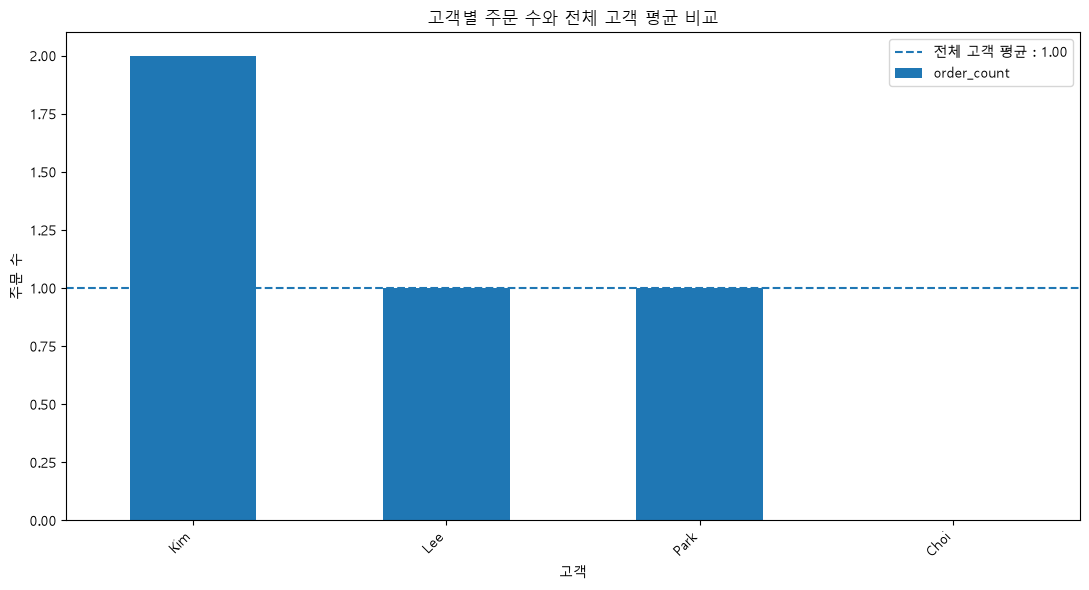

그래프 저장경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_count_vs_average.png


In [23]:
# 시각화
plot_df = df.sort_values(
    ["order_count", "customer_id"],
    ascending=[False, True]
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ax = plot_df.plot.bar(
    x = "customer_name",
    y = "order_count",
    figsize=(11,6),
    legend = False
)

ax.axhline(
    python_average,
    linestyle = "--",
    label = f"전체 고객 평균 : {python_average:.2f}"
)

ax.set_title("고객별 주문 수와 전체 고객 평균 비교")
ax.set_xlabel("고객")
ax.set_ylabel("주문 수")
ax.legend()

plt.xticks(
    rotation = 45,
    ha = "right"
)
plt.tight_layout()

figure_path = (
    output_dir / "customer_order_count_vs_average.png"
)

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()
print("그래프 저장경로:", figure_path)

In [ ]:
# CSV 저장
output_path = (
    output_dir / "customer_subquery_analysis.csv"
)

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("CSV 저장 경로:", output_path)

CSV 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_subquery_analysis.csv


In [ ]:
# 저장 결과 재확인
saved_df = pd.read_csv(
    output_path,
    parse_dates=[
        "first_order_date",
        "last_order_date",
    ]
)

print("저장된 CSV 크기:", saved_df.shape)
display(saved_df.head())

print("CSV 존재 여부:", output_path.exists())
print("PNG 존재 여부:", figure_path.exists())

저장된 CSV 크기: (4, 10)


,customer_id,customer_name,region,grade,order_count,first_order_date,last_order_date,has_order,avg_customer_order_count,comparison_group
0,1,Kim,Seoul,VIP,2,2026-07-20,2026-07-22,1,1.0,above_average
1,2,Lee,Busan,BASIC,1,2026-07-21,2026-07-21,1,1.0,average
2,3,Park,Seoul,GOLD,1,2026-07-23,2026-07-23,1,1.0,average
3,4,Choi,Incheon,BASIC,0,NaT,NaT,0,1.0,below_average


CSV 존재 여부: True
PNG 존재 여부: True


In [26]:
# 데이터베이스 연결 종료
conn.close()

print("SQLite 데이터베이스 연결 종료")

SQLite 데이터베이스 연결 종료


## 결과 해석

- 전체 고객의 평균 주문 수는 약 X건으로 확인됐다.
- 평균보다 주문 수가 많은 고객은 Y명이다.
- 주문 이력이 없는 고객은 Z명이다.
- 평균 초과 고객은 주문 활동이 상대적으로 높은 고객으로 볼 수 있으며, 유지 관리나 우선 분석 대상으로 검토할 수 있다.
- 주문 이력이 없는 고객은 재활성화 대상 후보로 분류할 수 있다.
- 다만 주문 횟수가 많다는 사실만으로 고객의 매출 기여도나 수익성이 높다고 판단할 수는 없다.

## 결과 해석

- 전체 고객의 평균 주문 수는 약 X건으로 확인됐다.
- 평균보다 주문 수가 많은 고객은 Y명이다.
- 주문 이력이 없는 고객은 Z명이다.
- 평균 초과 고객은 주문 활동이 상대적으로 높은 고객으로 볼 수 있으며, 유지 관리나 우선 분석 대상으로 검토할 수 있다.
- 주문 이력이 없는 고객은 재활성화 대상 후보로 분류할 수 있다.
- 다만 주문 횟수가 많다는 사실만으로 고객의 매출 기여도나 수익성이 높다고 판단할 수는 없다.